In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# ------------------------------
# Configuration
# ------------------------------

# Base data directory
DATA_DIR = r"E:\yr3\year_3_ai_ml\year_3_ai_ml\dstse\src\core\data"

# Data repository directory
DATA_REPO = os.path.join(DATA_DIR, "data_repo")
FEATURE_STORE=os.path.join(DATA_DIR, "feature_store")

# Input weather_data file
INPUT_FILE = os.path.join(DATA_REPO, "weather_data.csv")

# Input traffic_data file
INPUT_FILE_TRAFFIC = os.path.join(FEATURE_STORE, "traffic_for_lecture_system.csv")

# output file 
OUTPUT_FILE= os.path.join(FEATURE_STORE, "1_weather_data_with_categories.csv")


# Load weather data
print(f"Reading input file: {INPUT_FILE}")
df = pd.read_csv(INPUT_FILE, encoding='utf-8')
# If Date and Time are separate, combine them into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

Reading input file: C:\Users\User\bsse_software_projects\year_3\year_3_ai_ml\dstse\src\core\data\data_repo\weather_data.csv


In [35]:
# ------------------------------
# Initial Data Exploration
# ------------------------------

print("Shape:", df.shape)

print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

continuous_vars = ['Wet bulb', 'Dry bulb', 'Humidity', 'Wind speed']



Shape: (1098, 8)

Column names: ['Date', 'Time', 'Total Rainfall', 'Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed', 'datetime']

Data types:
 Date                         str
Time                         str
Total Rainfall           float64
Dry bulb                     str
Wet bulb                 float64
Humidity                 float64
Wind speed                 int64
datetime          datetime64[us]
dtype: object


In [36]:

print("\nFirst 5 rows:\n", df.head())



First 5 rows:
        Date   Time  Total Rainfall Dry bulb  Wet bulb  Humidity  Wind speed  \
0  3/1/2023   8:00             0.0     18.5      18.0      96.0           0   
1  3/1/2023   9:00             0.0     18.6      18.0      94.0           2   
2  3/1/2023  10:00             0.0     21.4      19.4      83.0           2   
3  3/1/2023  11:00             0.0     23.5      20.0      70.0           2   
4  3/1/2023  12:00             0.0     25.0      20.4      65.0           4   

             datetime  
0 2023-03-01 08:00:00  
1 2023-03-01 09:00:00  
2 2023-03-01 10:00:00  
3 2023-03-01 11:00:00  
4 2023-03-01 12:00:00  


In [37]:
print("\nLast 5 rows:\n", df.tail())



Last 5 rows:
            Date   Time  Total Rainfall Dry bulb  Wet bulb  Humidity  \
1093  6/30/2023  12:00            27.0     18.5      18.5     100.0   
1094  6/30/2023  13:00            27.0     21.0      19.5      87.0   
1095  6/30/2023  14:00            27.0     24.0      20.5      73.0   
1096  6/30/2023  15:00            27.0     24.2      20.5      72.0   
1097  6/30/2023  16:00            27.0     24.2      20.2      70.0   

      Wind speed            datetime  
1093           0 2023-06-30 12:00:00  
1094           0 2023-06-30 13:00:00  
1095           0 2023-06-30 14:00:00  
1096           2 2023-06-30 15:00:00  
1097           2 2023-06-30 16:00:00  


In [38]:
print("\nBasic statistics:\n", df.describe(include='all'))



Basic statistics:
              Date  Time  Total Rainfall Dry bulb     Wet bulb     Humidity  \
count        1098  1098     1098.000000     1098  1098.000000  1098.000000   
unique        122     9             NaN      104          NaN          NaN   
top     6/10/2023  8:00             NaN     26.0          NaN          NaN   
freq           11   122             NaN       48          NaN          NaN   
mean          NaN   NaN        6.736066      NaN    20.141166    73.387978   
min           NaN   NaN        0.000000      NaN    16.800000    44.000000   
25%           NaN   NaN        0.000000      NaN    19.500000    62.000000   
50%           NaN   NaN        0.450000      NaN    20.400000    70.000000   
75%           NaN   NaN        7.300000      NaN    21.000000    84.750000   
max           NaN   NaN       83.300000      NaN    22.400000   100.000000   
std           NaN   NaN       12.799316      NaN     0.946509    13.421188   

         Wind speed                    date

In [39]:
df.isnull().sum()

Date              0
Time              0
Total Rainfall    0
Dry bulb          0
Wet bulb          0
Humidity          0
Wind speed        0
datetime          0
dtype: int64

In [40]:
# ------------------------------
# Cast String(Dry bulb) to float 
# ------------------------------

df['Dry bulb']= pd.to_numeric(df['Dry bulb'], errors='coerce')
print("\nData types:\n", df.dtypes)



Data types:
 Date                         str
Time                         str
Total Rainfall           float64
Dry bulb                 float64
Wet bulb                 float64
Humidity                 float64
Wind speed                 int64
datetime          datetime64[us]
dtype: object


In [41]:
df.isnull().sum()

Date              0
Time              0
Total Rainfall    0
Dry bulb          1
Wet bulb          0
Humidity          0
Wind speed        0
datetime          0
dtype: int64

In [ ]:
def fillna_with_interpolation(df, col, value):
    """"
       Takes a DataFrame, column name, and value to replace. 
       It replaces the value with NaN, 
       then uses linear interpolation to fill in the missing values.

       return the DataFrame with the specified column's missing values filled in.  

   """
    # sorting dataframe by datetime to ensure interpolation is done in the correct order
    df = df.sort_values('datetime').reset_index(drop=True)
    if value:
        float_val= float(value)
        # first replacing 0.0 with NaN to make it clear that it's missing
        df[col] = df[col].replace(float_val, np.nan)

    # Interpolate the Dry bulb column using linear interpolation method
    df[col] = df[col].interpolate(method='linear')

    return df

In [43]:
col='Dry bulb'
df=fillna_with_interpolation(df,col, value=None)

# Verify the fix
df.isnull().sum()

Date              0
Time              0
Total Rainfall    0
Dry bulb          0
Wet bulb          0
Humidity          0
Wind speed        0
datetime          0
dtype: int64

In [ ]:
# this was rejected because it was not clear that the 0.0 value was missing,
# and interpolation is a better method to fill in the missing values than just using the mean, 
# especially for time series data where the values can change over time.



# # calculate mean of 'Dry bulb' column
# mean_val=df['Dry bulb'].mean()

# print(f"\nMean of 'Dry bulb': {mean_val:.2f}")
# # fill all the missing values with mean
# # its only one, nd this app is not critical
# df['Dry bulb']=df['Dry bulb'].fillna(mean_val)

# # check for null
# df.isnull().sum()

In [ ]:
# Function to detect outliers using IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

outliers_db = detect_outliers_iqr(df, 'Dry bulb')
print("Dry bulb outliers:")
print(outliers_db[['datetime', 'Dry bulb', 'Total Rainfall', 'Humidity', 'Wind speed']])

Dry bulb outliers:
               datetime  Dry bulb  Total Rainfall  Humidity  Wind speed
397 2023-04-14 09:00:00       0.0             0.6      93.0           0


In [ ]:
# Get index of the outlier
idx = outliers_db.index[0]
# Show a window around it (using ±3 hours). 
# This will help us see if there are any patterns or anomalies around the outlier that might explain it.
# we found out that it was just a data entry error

window = df.loc[max(0, idx-3): min(len(df)-1, idx+3), ['datetime', 'Dry bulb', 'Total Rainfall']]
print("\nNearby records:")
print(window)


Nearby records:
               datetime  Dry bulb  Total Rainfall
394 2023-04-13 15:00:00      26.5            12.8
395 2023-04-13 16:00:00      26.0            12.8
396 2023-04-14 08:00:00      19.2             0.6
397 2023-04-14 09:00:00       0.0             0.6
398 2023-04-14 10:00:00      20.8             0.6
399 2023-04-14 11:00:00      23.8             0.6
400 2023-04-14 12:00:00      26.5             0.6


In [47]:
col='Dry bulb'
value=0.0
df=fillna_with_interpolation(df,col,value="0.0")

# Verify the fix
print(df.loc[394:400, ['datetime', 'Dry bulb', 'Total Rainfall']])

               datetime  Dry bulb  Total Rainfall
394 2023-04-13 15:00:00      26.5            12.8
395 2023-04-13 16:00:00      26.0            12.8
396 2023-04-14 08:00:00      19.2             0.6
397 2023-04-14 09:00:00      20.0             0.6
398 2023-04-14 10:00:00      20.8             0.6
399 2023-04-14 11:00:00      23.8             0.6
400 2023-04-14 12:00:00      26.5             0.6


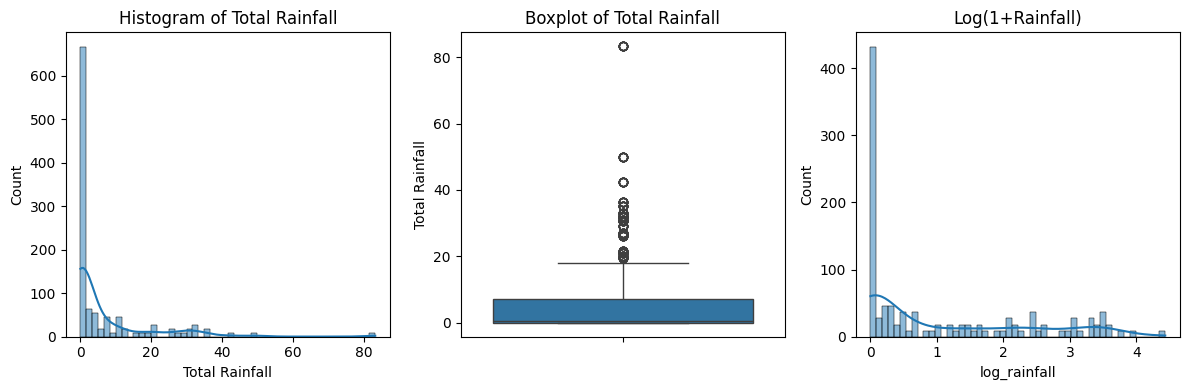

In [ ]:
# ------------------------------
# Rainfall analysis
# ------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(df['Total Rainfall'], bins=50, kde=True)
plt.title('Histogram of Total Rainfall')

plt.subplot(1,3,2)
sns.boxplot(y=df['Total Rainfall'])
plt.title('Boxplot of Total Rainfall')

plt.subplot(1,3,3)
# Log transform to see the distribution better, and adding small constant to avoid log(0))
df['log_rainfall'] = np.log1p(df['Total Rainfall'])
sns.histplot(df['log_rainfall'], bins=50, kde=True)
plt.title('Log(1+Rainfall)')

plt.tight_layout()
plt.show()

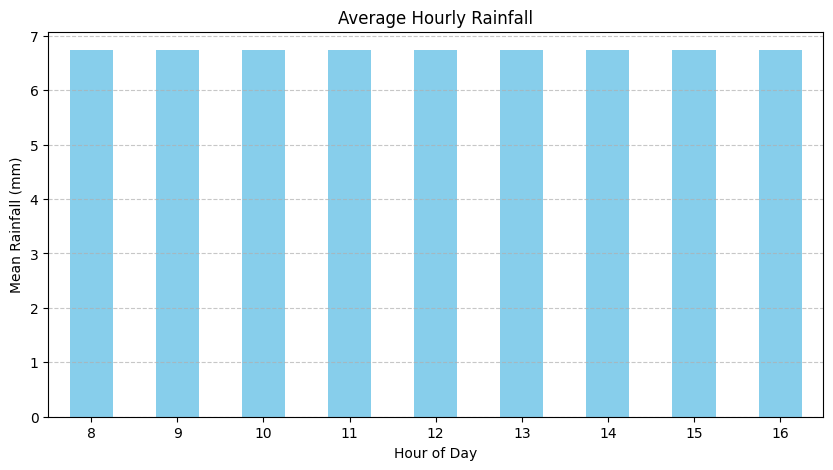

hour
8     6.736066
9     6.736066
10    6.736066
11    6.736066
12    6.736066
13    6.736066
14    6.736066
15    6.736066
16    6.736066
Name: Total Rainfall, dtype: float64


In [49]:
# ------------------------------
# Hourly rainfall
# ------------------------------

# Extract hour from datetime
df['hour'] = df['datetime'].dt.hour

hourly_avg_rain = df.groupby('hour')['Total Rainfall'].mean()

# Plot
plt.figure(figsize=(10,5))
hourly_avg_rain.plot(kind='bar', color='skyblue')
plt.title('Average Hourly Rainfall')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Rainfall (mm)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(hourly_avg_rain)

In [50]:
print("Unique hours in dataset:", sorted(df['hour'].unique()))
print("Number of records per hour:")
print(df['hour'].value_counts().sort_index())

Unique hours in dataset: [np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16)]
Number of records per hour:
hour
8     122
9     122
10    122
11    122
12    122
13    122
14    122
15    122
16    122
Name: count, dtype: int64


In [51]:

# Filter for positive rainfall only
positive_rainfall = df[df['Total Rainfall'] > 0]['Total Rainfall']

# Calculate the 33rd and 66th percentiles
light_threshold = positive_rainfall.quantile(0.33)
moderate_threshold = positive_rainfall.quantile(0.66)

print(f"Positive rainfall statistics:")
print(f"Total rainy records: {len(positive_rainfall)}")
print(f"Min rainfall: {positive_rainfall.min():.2f} mm")
print(f"Max rainfall: {positive_rainfall.max():.2f} mm")
print(f"\nQuantile thresholds:")
print(f"33rd percentile (Light/Moderate boundary): {light_threshold:.2f} mm")
print(f"66th percentile (Moderate/Heavy boundary): {moderate_threshold:.2f} mm")

# check the full distribution
print(f"\nFull quantiles:")
print(positive_rainfall.quantile([0.25, 0.5, 0.75, 0.9, 0.95]))

Positive rainfall statistics:
Total rainy records: 666
Min rainfall: 0.10 mm
Max rainfall: 83.30 mm

Quantile thresholds:
33rd percentile (Light/Moderate boundary): 1.40 mm
66th percentile (Moderate/Heavy boundary): 10.30 mm

Full quantiles:
0.25     0.60
0.50     4.05
0.75    18.00
0.90    31.90
0.95    36.50
Name: Total Rainfall, dtype: float64


In [52]:
# assign categories
def categorize_rainfall(rainfall):
    if rainfall == 0:
        return 0  # No Rain
    elif rainfall <= light_threshold:
        return 1  # Light Rain
    elif rainfall <= moderate_threshold:
        return 2  # Moderate Rain
    else:
        return 3  # Heavy Rain

# categorize
df['rain_category'] = df['Total Rainfall'].apply(categorize_rainfall)

# Add descriptive labels for interpretation
category_names = {
    0: 'No Rain',
    1: 'Light Rain',
    2: 'Moderate Rain',
    3: 'Heavy Rain'
}
df['rain_label'] = df['rain_category'].map(category_names)

# Check the distribution
print("Category distribution:")
print(df['rain_label'].value_counts())
print("\nPercentages:")
print(df['rain_label'].value_counts(normalize=True) * 100)

Category distribution:
rain_label
No Rain          432
Heavy Rain       225
Light Rain       225
Moderate Rain    216
Name: count, dtype: int64

Percentages:
rain_label
No Rain          39.344262
Heavy Rain       20.491803
Light Rain       20.491803
Moderate Rain    19.672131
Name: proportion, dtype: float64



Rainfall statistics by category:
               count   min   max       mean  median
rain_label                                         
Heavy Rain       225  10.4  83.3  27.552000   26.60
Light Rain       225   0.1   1.4   0.528000    0.40
Moderate Rain    216   1.5  10.3   4.991667    4.05
No Rain          432   0.0   0.0   0.000000    0.00


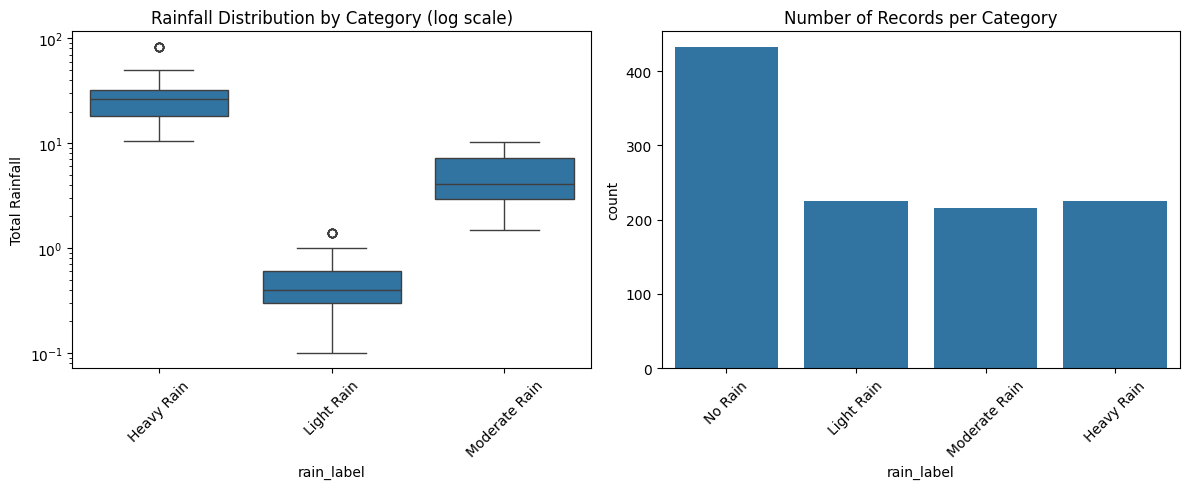

In [53]:
# Show rainfall statistics for each category
category_stats = df.groupby('rain_label')['Total Rainfall'].agg(['count', 'min', 'max', 'mean', 'median'])
print("\nRainfall statistics by category:")
print(category_stats)

# Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Box plot
plt.subplot(1, 2, 1)
sns.boxplot(x='rain_label', y='Total Rainfall', data=df[df['Total Rainfall'] > 0])
plt.yscale('log')
plt.title('Rainfall Distribution by Category (log scale)')
plt.xticks(rotation=45)

# Count plot
plt.subplot(1, 2, 2)
sns.countplot(x='rain_label', data=df, order=['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain'])
plt.title('Number of Records per Category')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Check if categories are reasonably balanced for rainy days only thus (df['Total Rainfall'] > 0)
rainy_categories = df[df['Total Rainfall'] > 0]['rain_label'].value_counts()
print("Rainy day category distribution:")
print(rainy_categories)
print(f"\nBalance ratio (max/min): {rainy_categories.max() / rainy_categories.min():.2f}")

Rainy day category distribution:
rain_label
Heavy Rain       225
Light Rain       225
Moderate Rain    216
Name: count, dtype: int64

Balance ratio (max/min): 1.04


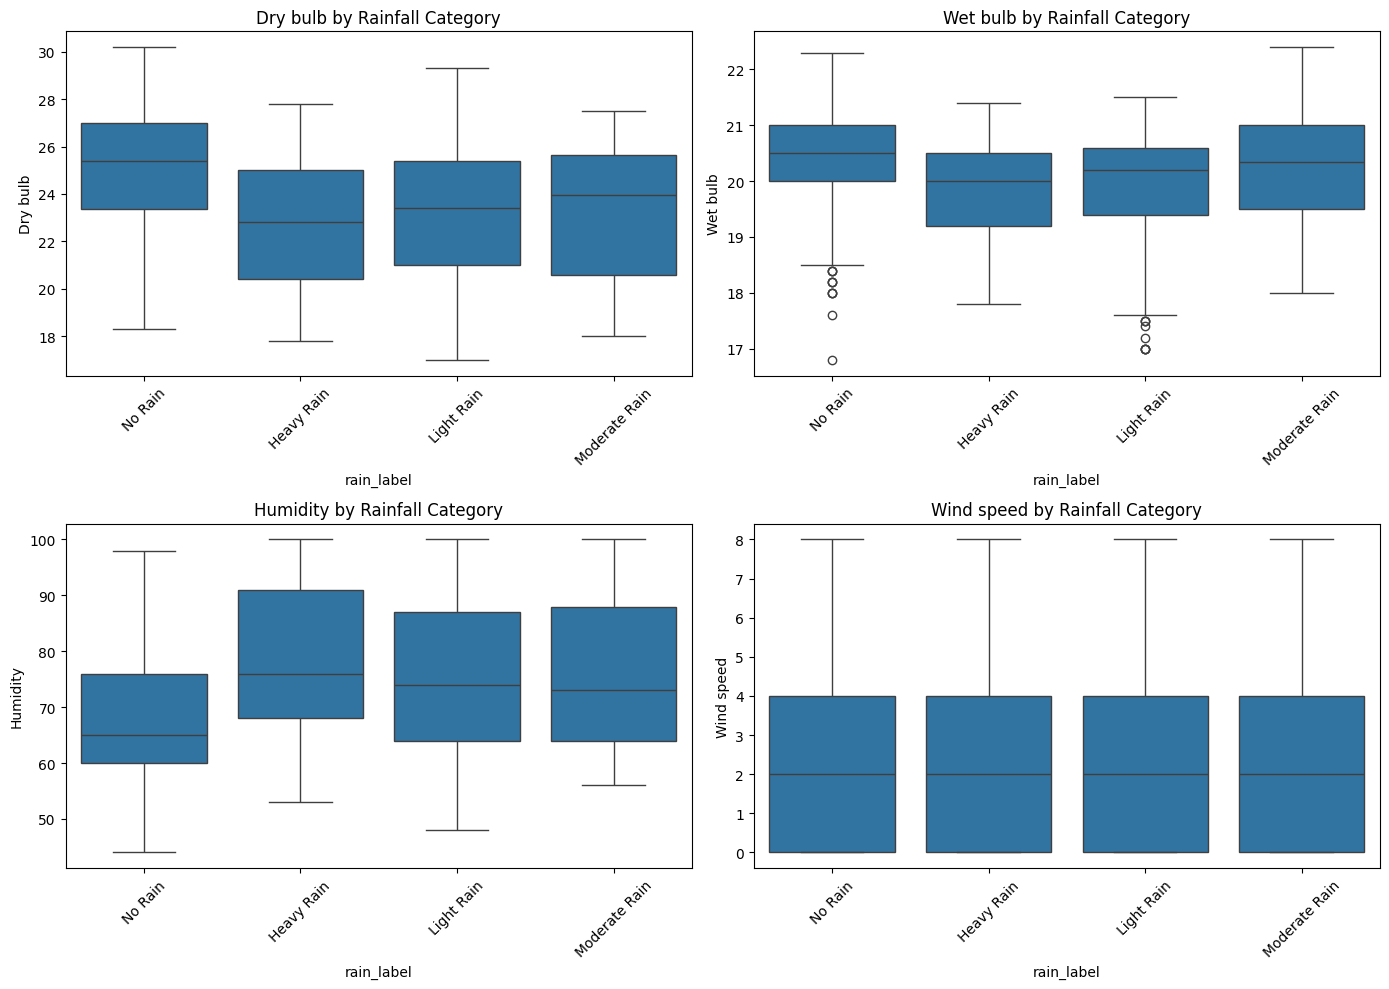


Mean values by category:
                Dry bulb   Wet bulb   Humidity  Wind speed
rain_label                                                
Heavy Rain     22.623111  19.802222  78.533333    1.773333
Light Rain     23.128889  19.927556  75.951111    2.248889
Moderate Rain  23.335185  20.112500  75.847222    2.050926
No Rain        24.856481  20.443287  68.143519    2.428241


In [ ]:
# Create a boxplots for each predictor by category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
predictors = ['Dry bulb', 'Wet bulb', 'Humidity', 'Wind speed']

for i, pred in enumerate(predictors):
    row, col = i // 2, i % 2
    sns.boxplot(x='rain_label', y=pred, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{pred} by Rainfall Category')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# check the mean values
print("\nMean values by category:")
print(df.groupby('rain_label')[predictors].mean())

In [56]:
# Save the dataframe with the new category column
df.to_csv(OUTPUT_FILE, index=False)
print("Saved data with categories to 'weather_data_with_categories.csv'")

Saved data with categories to 'weather_data_with_categories.csv'


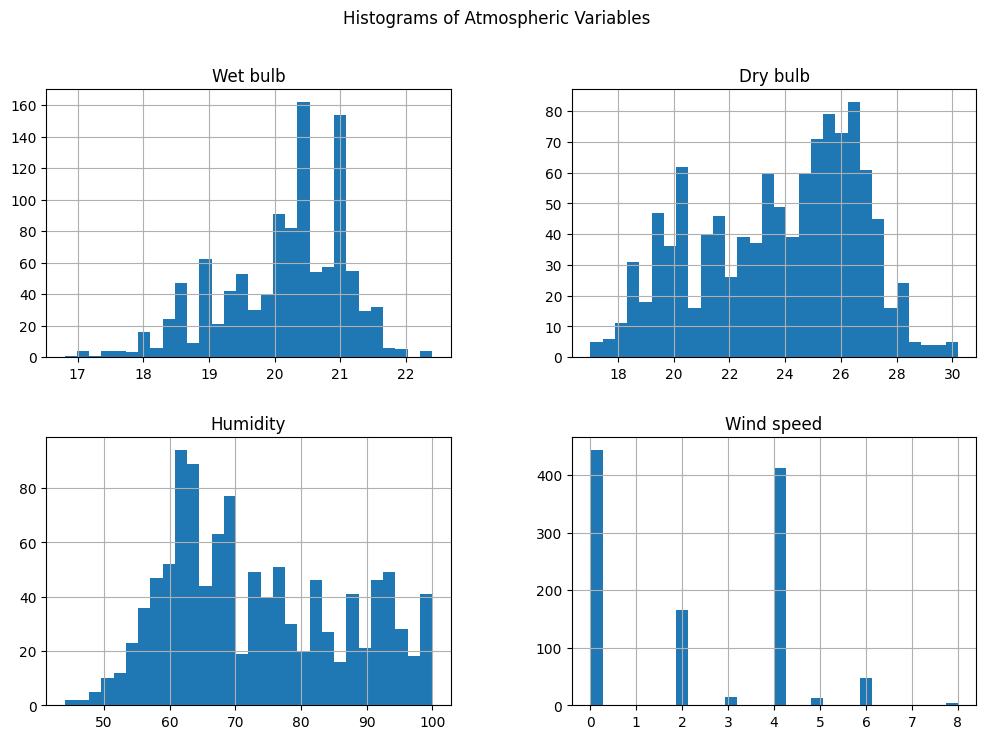

In [57]:
# ------------------------------
# Dry Bulb Temperature, Wet Bulb Temperature, Humidity, Wind Speed
# ------------------------------

df[continuous_vars].hist(bins=30, figsize=(12,8))
plt.suptitle('Histograms of Atmospheric Variables')
plt.show()

In [58]:
# ------------------------------
# Wet Bulb 
# ------------------------------

outliers_wb = detect_outliers_iqr(df, 'Wet bulb')
print("Wet bulb outliers:")
print(outliers_wb[['datetime', 'Wet bulb', 'Total Rainfall', 'Dry bulb', 'Humidity']])

Wet bulb outliers:
               datetime  Wet bulb  Total Rainfall  Dry bulb  Humidity
19  2023-03-03 09:00:00      17.0             0.4      17.0     100.0
20  2023-03-03 10:00:00      17.2             0.4      17.2     100.0
21  2023-03-03 11:00:00      17.0             0.4      17.3      97.0
172 2023-03-20 09:00:00      17.0             0.5      17.0     100.0
180 2023-03-21 08:00:00      16.8             0.0      18.3      86.0
207 2023-03-24 08:00:00      17.0             0.6      18.8      83.0


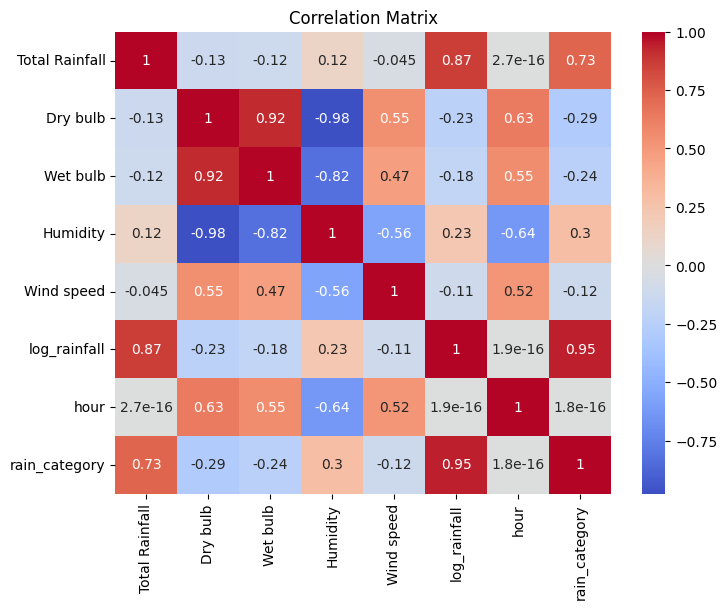

In [ ]:

# ------------------------------
# Correlation analysis
# ------------------------------
# only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

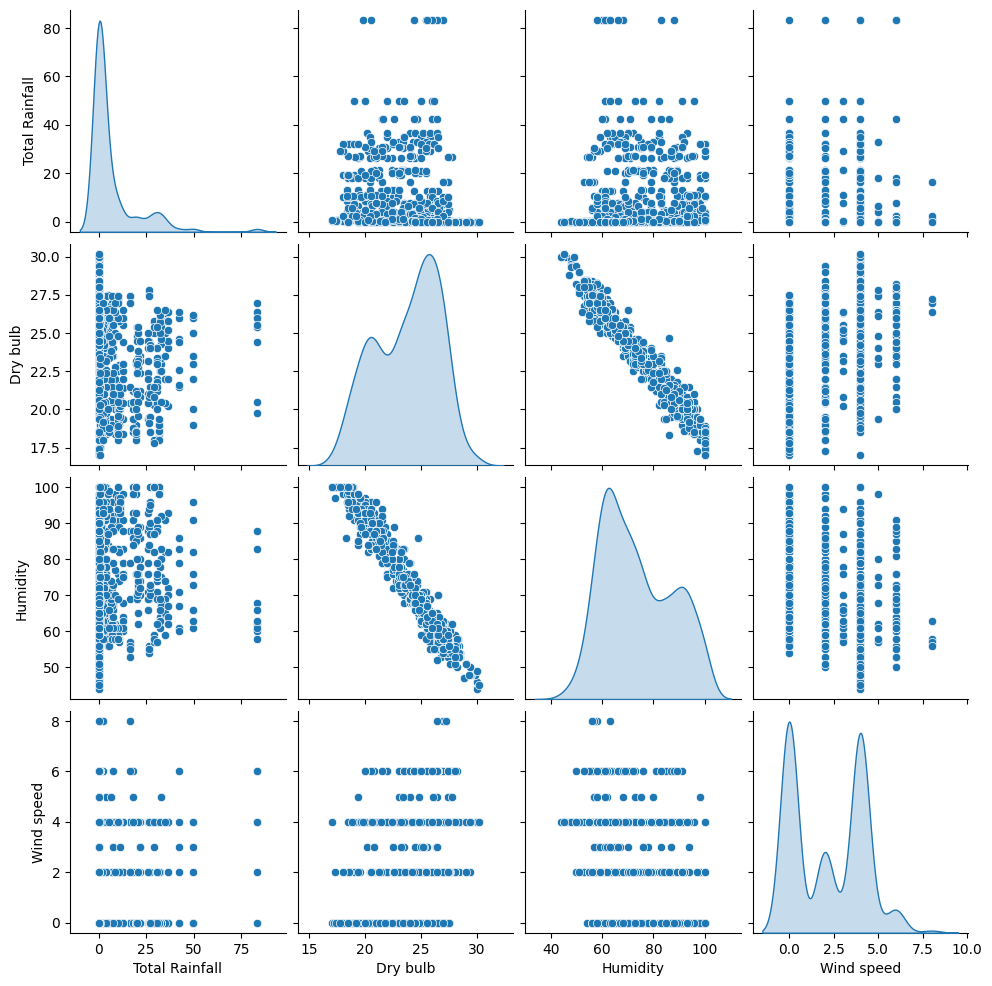

In [ ]:

# ------------------------------
# Pair analysis
# ------------------------------

sns.pairplot(df[['Total Rainfall', 'Dry bulb', 'Humidity', 'Wind speed']].sample(1000), diag_kind='kde')
plt.show()

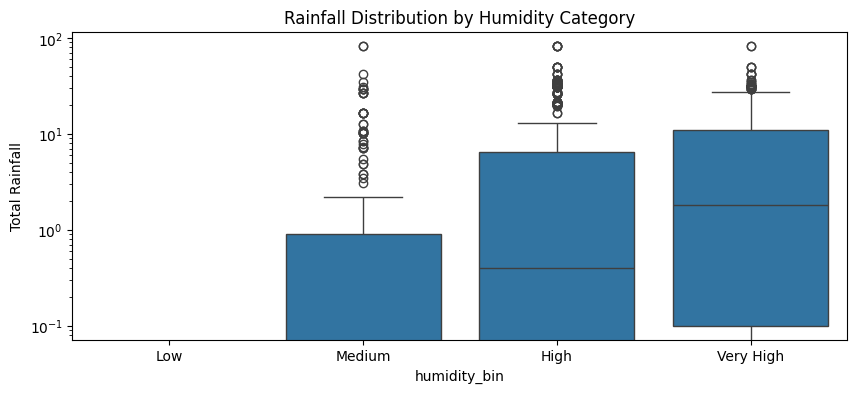

In [ ]:

# ------------------------------
# Conditional Distrution
# ------------------------------
# Create humidity bins
df['humidity_bin'] = pd.cut(df['Humidity'], bins=[0, 30, 60, 80, 100], labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(10,4))
sns.boxplot(x='humidity_bin', y='Total Rainfall', data=df)
plt.yscale('log')  # log scale to see details
plt.title('Rainfall Distribution by Humidity Category')
plt.show()

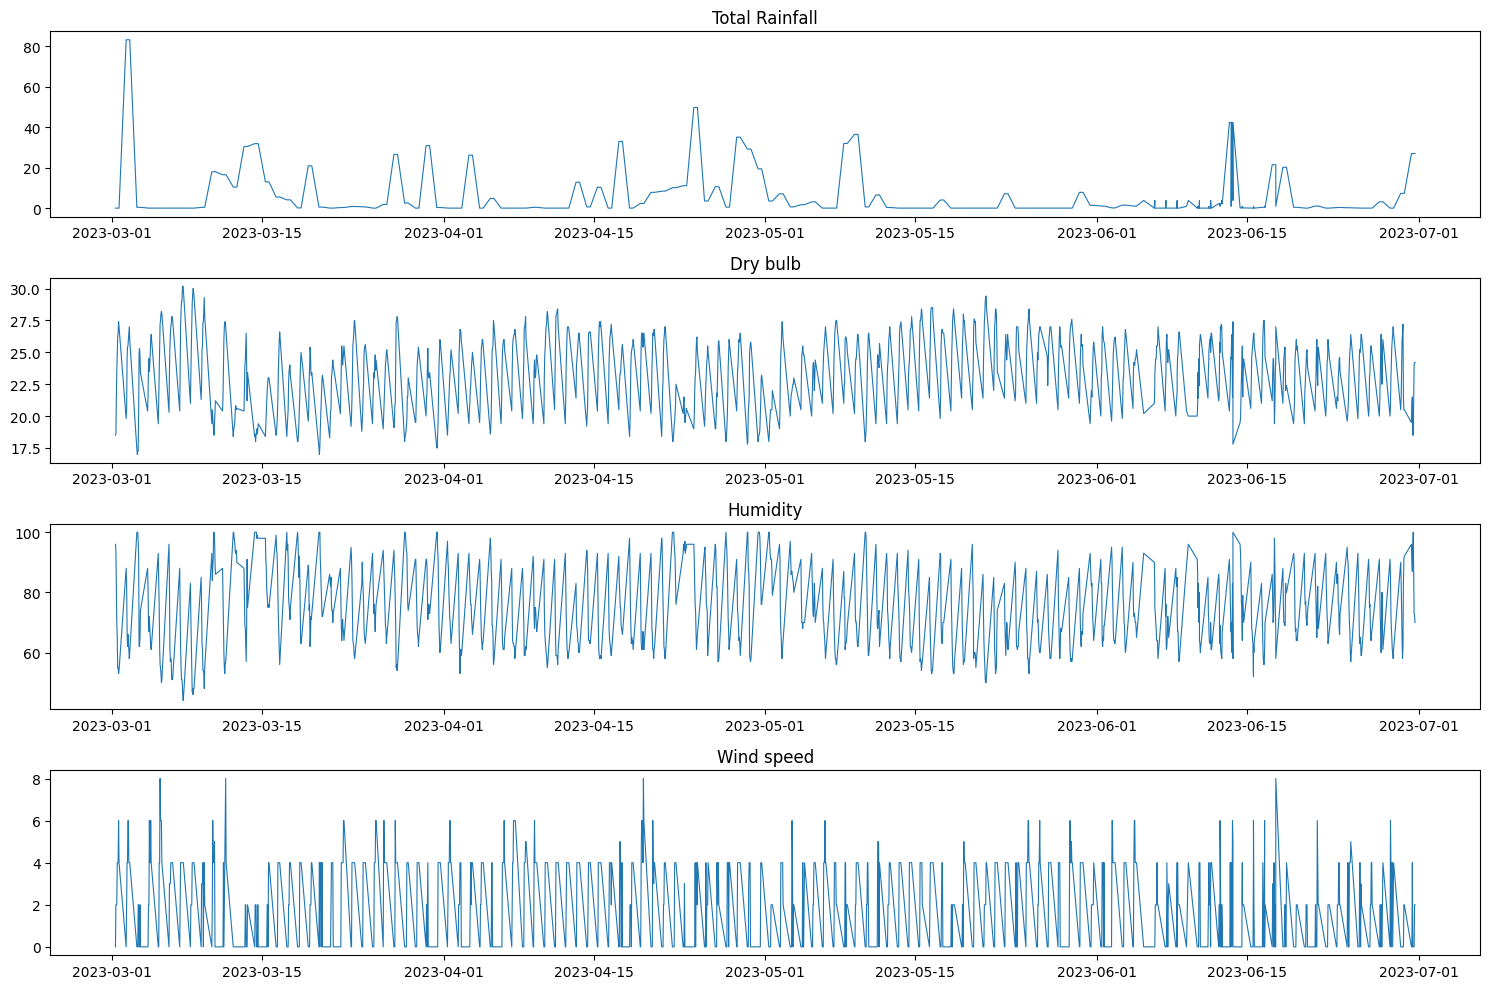

In [ ]:
# ------------------------------
# Trends over time
# ------------------------------

# sort data by datetime
df = df.sort_values('datetime').reset_index(drop=True)

plt.figure(figsize=(15,10))
for i, var in enumerate(['Total Rainfall', 'Dry bulb', 'Humidity', 'Wind speed']):
    plt.subplot(4,1,i+1)
    plt.plot(df['datetime'], df[var], linewidth=0.8)
    plt.title(var)
plt.tight_layout()
plt.show()

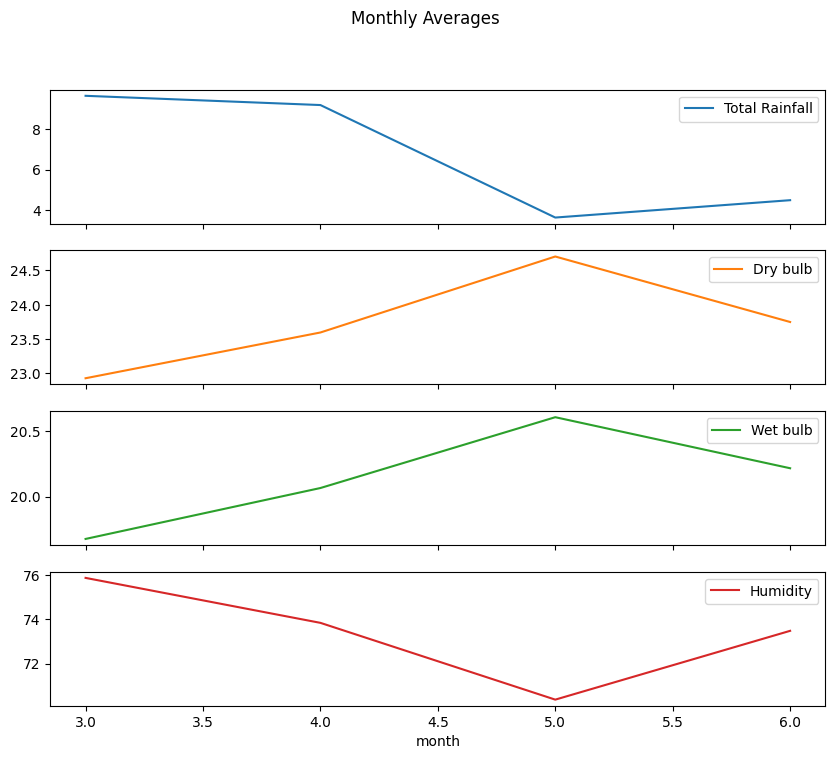

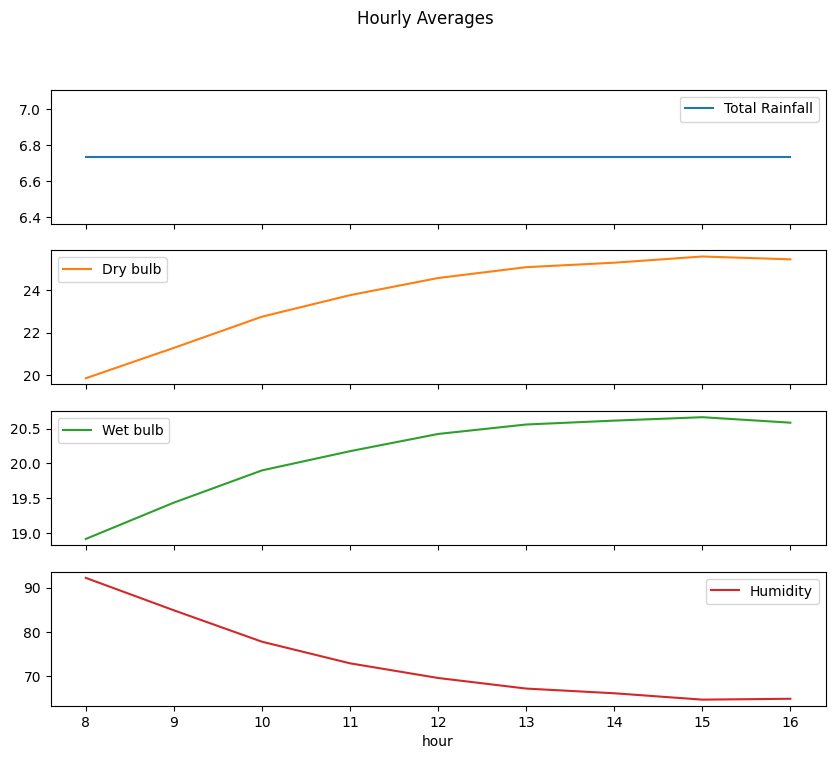

In [63]:
# ------------------------------
# Seasonal Pattern
# ------------------------------

df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['year'] = df['datetime'].dt.year

# Monthly averages
monthly_avg = df.groupby('month')[['Total Rainfall', 'Dry bulb','Wet bulb','Humidity']].mean()
monthly_avg.plot(subplots=True, figsize=(10,8))
plt.suptitle('Monthly Averages')
plt.show()

# Diurnal pattern (if data is sub‑daily)
hourly_avg = df.groupby('hour')[['Total Rainfall', 'Dry bulb','Wet bulb', 'Humidity']].mean()
hourly_avg.plot(subplots=True, figsize=(10,8))
plt.suptitle('Hourly Averages')
plt.show()

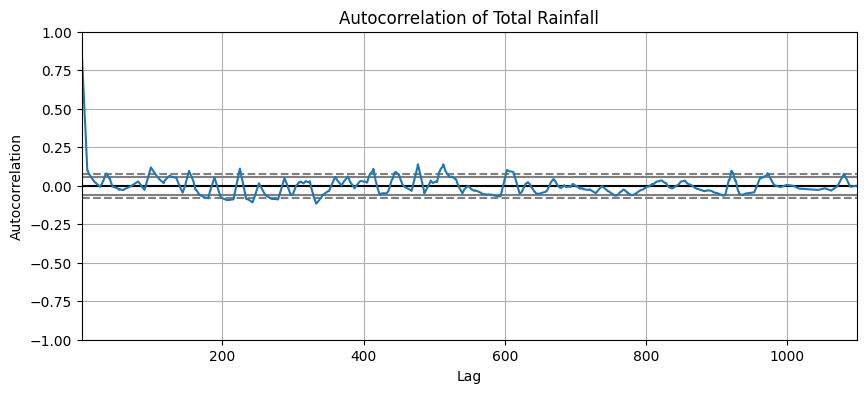

In [64]:
# ------------------------------
# Lag annalysis
# ------------------------------

from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10,4))
autocorrelation_plot(df['Total Rainfall'].dropna())
plt.title('Autocorrelation of Total Rainfall')
plt.show()

In [65]:
# ------------------------------
# Handling Zeros
# ------------------------------

zero_rain = (df['Total Rainfall'] == 0).mean()
print(f"Proportion of zero‑rain days: {zero_rain:.2%}")

Proportion of zero‑rain days: 39.34%


# VISUALIZATIONS AFTER FEATURE ENGINEERING, BEFORE MODEL TRAINING

### WEATHER DATA

In [8]:
INPUT_FILE=os.path.join(DATA_DIR,"feature_store", "reg_ts_categorised_weather_data_with_features.csv")

In [ ]:
# Load weather data
print(f"Reading input file: {INPUT_FILE}")
df = pd.read_csv(INPUT_FILE, encoding='utf-8')
# combining date and time into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

Reading input file: C:\Users\User\bsse_software_projects\year_3\year_3_ai_ml\dstse\src\core\data\feature_store\reg_ts_categorised_weather_data_with_features.csv


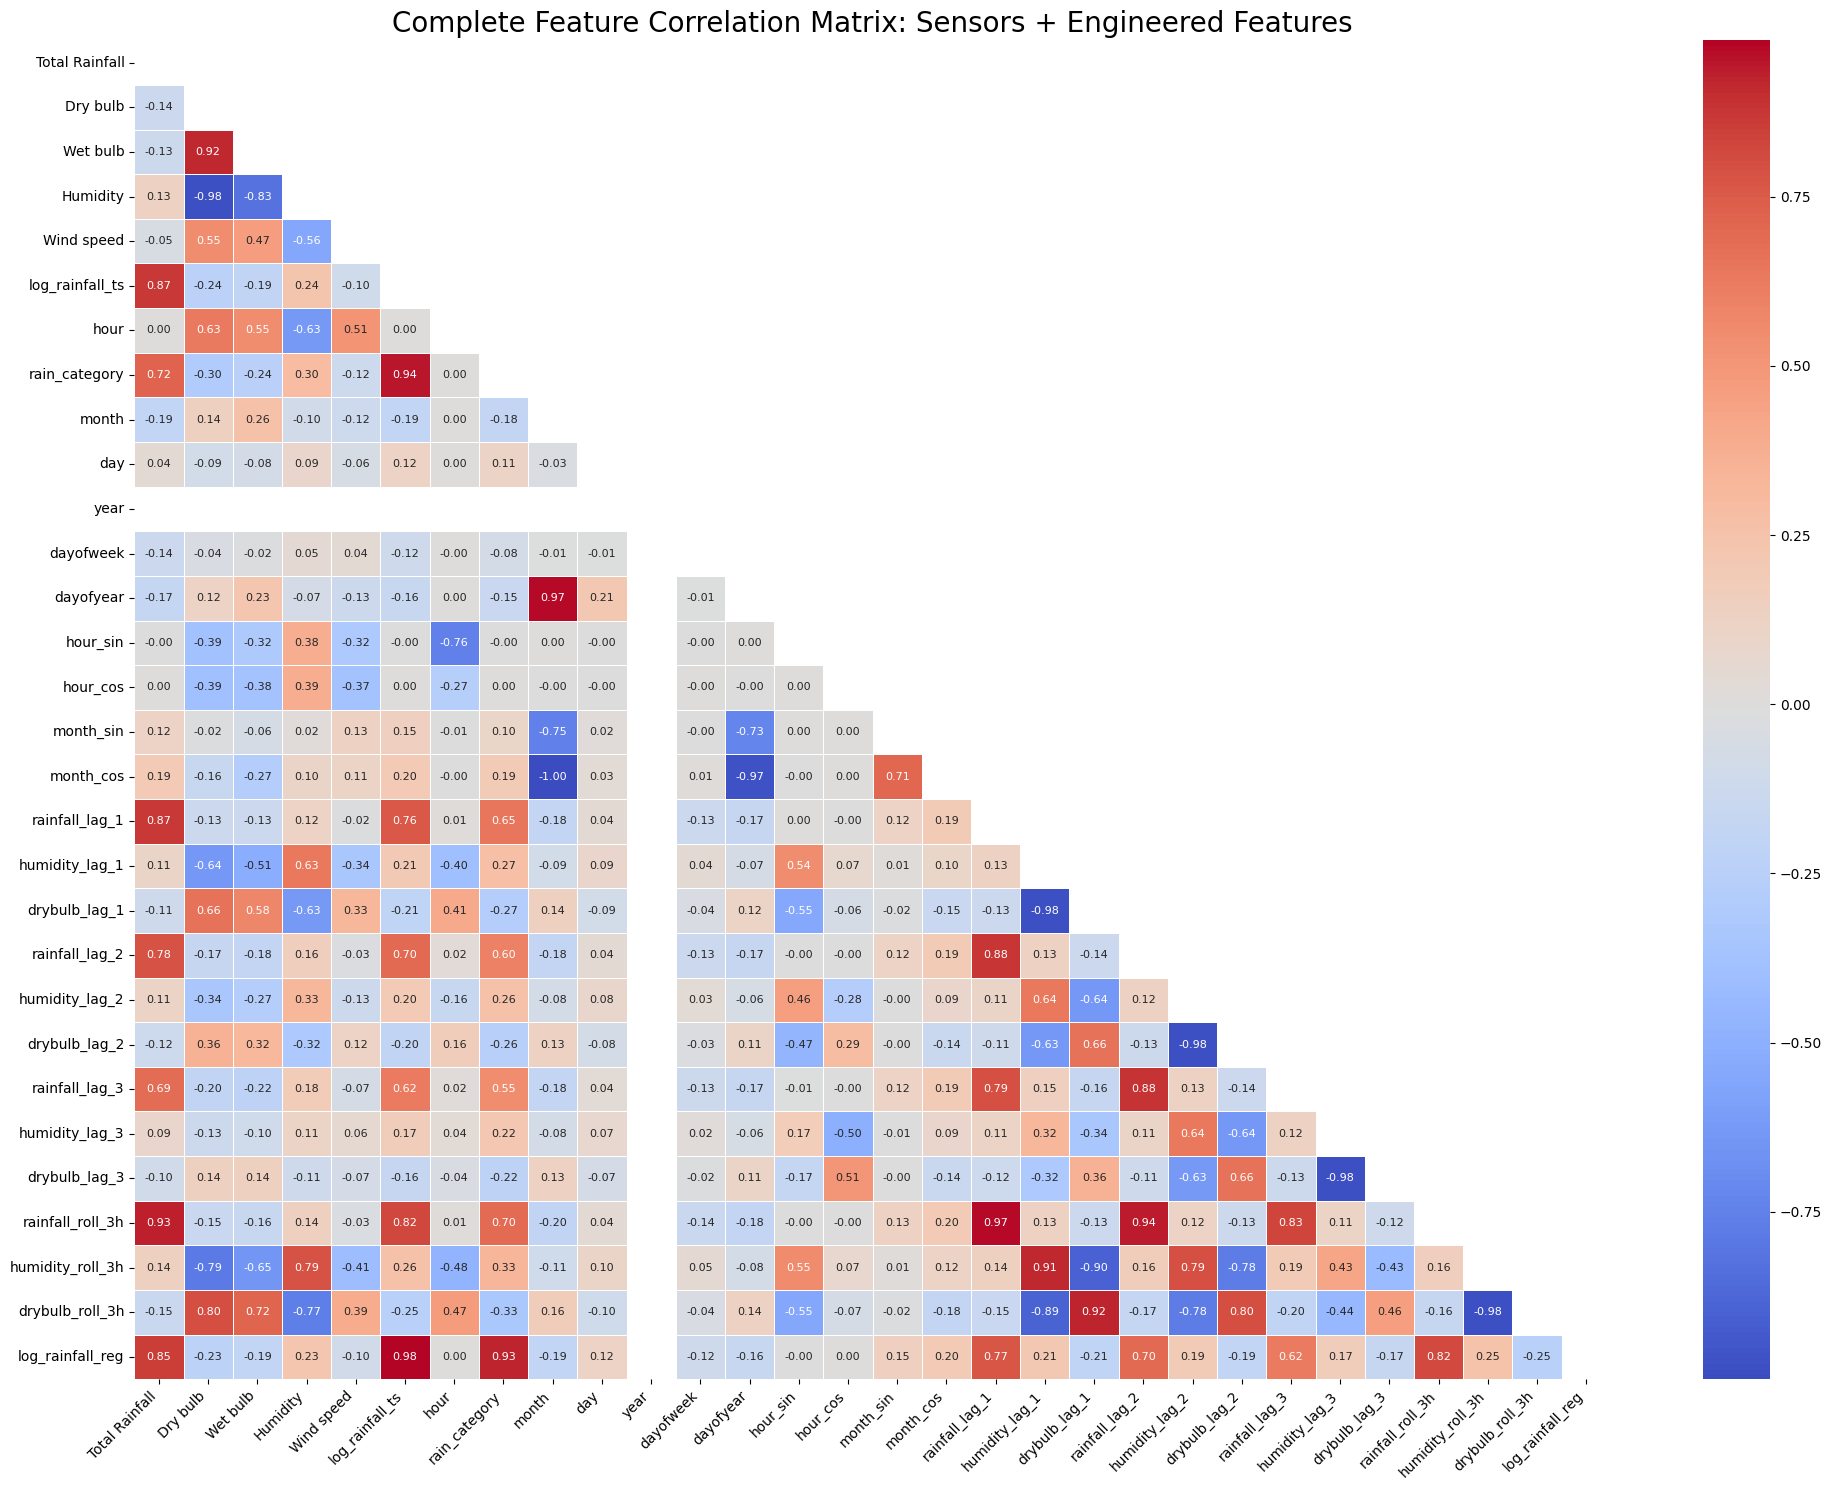

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Generate a Large-Scale Heatmap
# 20x15 size to ensure labels aren't squashed
plt.figure(figsize=(20, 15))

# Mask the upper triangle because its always a mirror image, so we hide it for clarity
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          # Show the numbers
    fmt=".2f",           # 2 decimal places
    cmap='coolwarm',     # Red (Positive), Blue (Negative)
    linewidths=0.5,
    annot_kws={"size": 8} # Smaller font for the numbers so they fit in the squares
)

plt.title('Complete Feature Correlation Matrix: Sensors + Engineered Features', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## TRAFFIC DATA

In [ ]:
# Load traffic data
print(f"Reading input file: {INPUT_FILE_TRAFFIC}")
df = pd.read_csv(INPUT_FILE_TRAFFIC)



Reading input file: C:\Users\User\bsse_software_projects\year_3\year_3_ai_ml\dstse\src\core\data\feature_store\traffic_for_lecture_system.csv


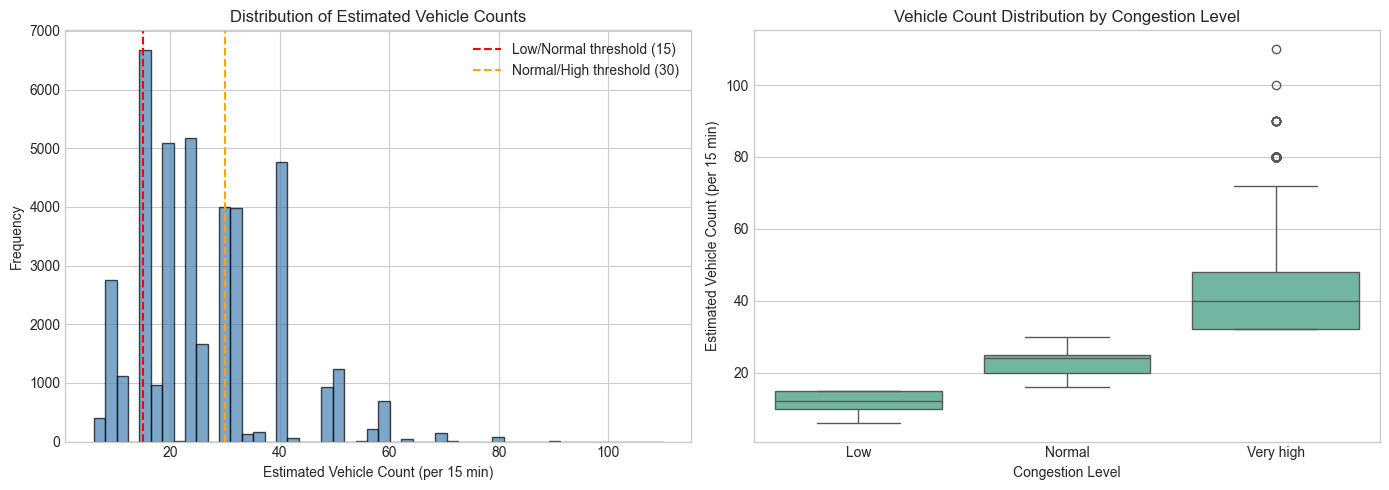

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of estimated vehicle counts
axes[0].hist(df['estimated_vehicle_count'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Estimated Vehicle Count (per 15 min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Estimated Vehicle Counts')
axes[0].axvline(x=15, color='red', linestyle='--', label='Low/Normal threshold (15)')
axes[0].axvline(x=30, color='orange', linestyle='--', label='Normal/High threshold (30)')
axes[0].legend()

# Boxplot by congestion level
sns.boxplot(x='congestion', y='estimated_vehicle_count', data=df, ax=axes[1])
axes[1].set_xlabel('Congestion Level')
axes[1].set_ylabel('Estimated Vehicle Count (per 15 min)')
axes[1].set_title('Vehicle Count Distribution by Congestion Level')

plt.tight_layout()
plt.savefig('traffic_distribution.png', dpi=300)
plt.show()

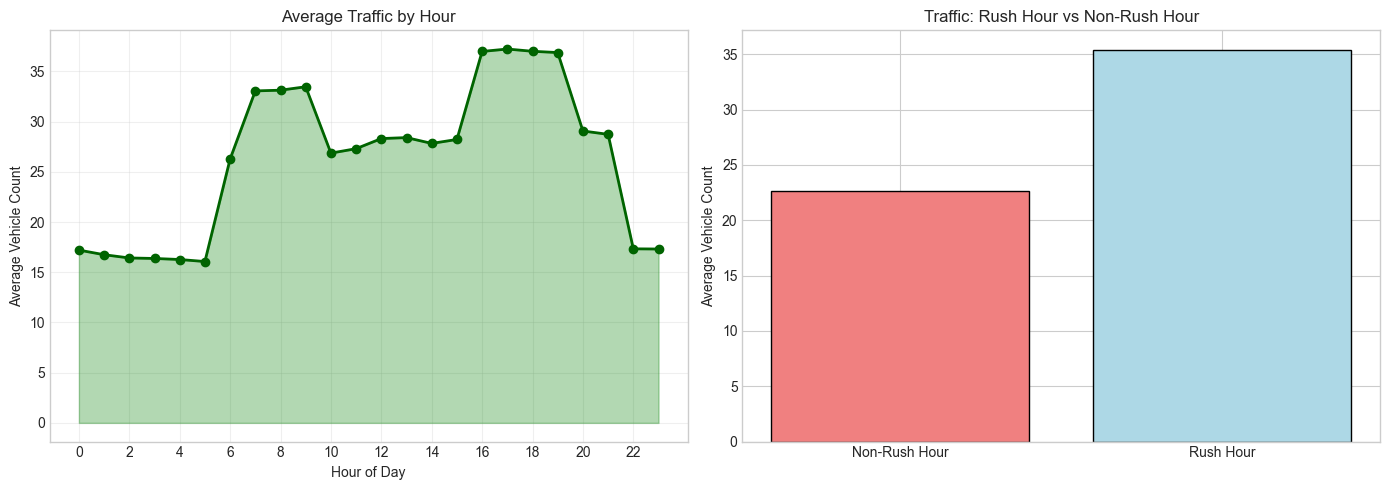

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average traffic by hour
hourly_avg = df.groupby('hour')['estimated_vehicle_count'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='darkgreen')
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.3, color='green')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Vehicle Count')
axes[0].set_title('Average Traffic by Hour')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# Rush hour vs non-rush hour
rush_comparison = df.groupby('is_rush_hour')['estimated_vehicle_count'].mean()
colors = ['lightcoral', 'lightblue']
axes[1].bar(['Non-Rush Hour', 'Rush Hour'], rush_comparison.values, color=colors, edgecolor='black')
axes[1].set_ylabel('Average Vehicle Count')
axes[1].set_title('Traffic: Rush Hour vs Non-Rush Hour')

plt.tight_layout()
plt.savefig('hourly_traffic_patterns.png', dpi=300)
plt.show()

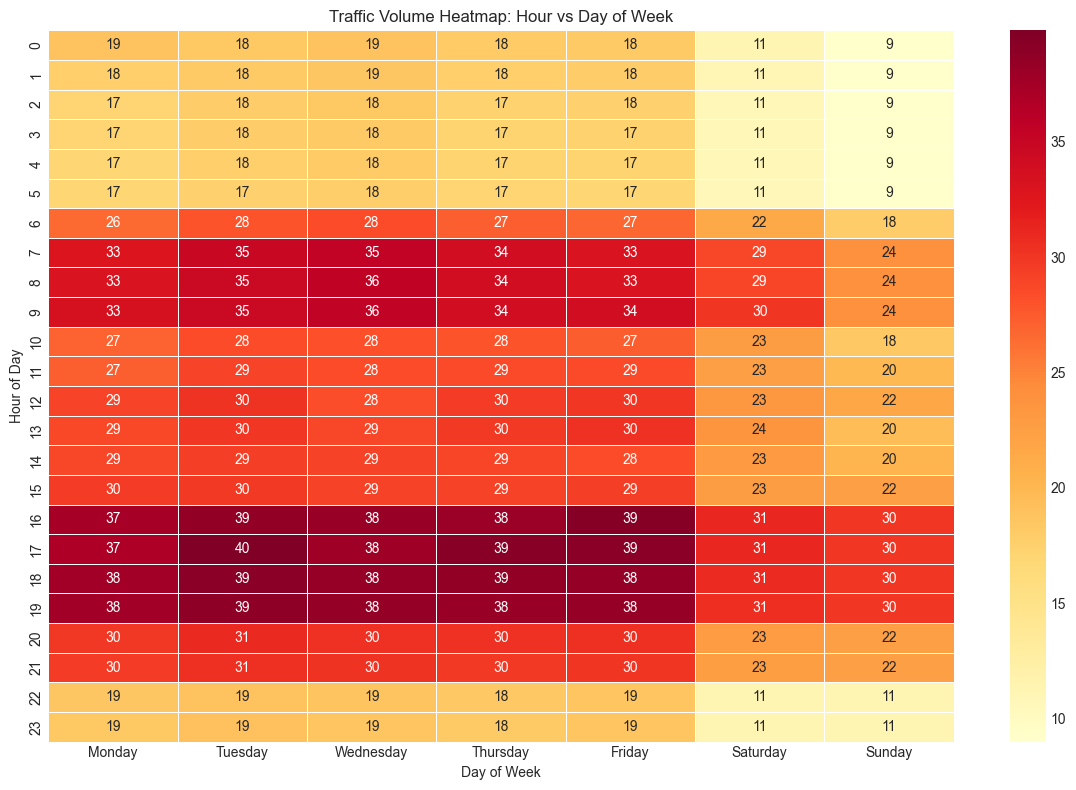

In [10]:
# Create pivot table for heatmap
heatmap_data = df.pivot_table(
    values='estimated_vehicle_count', 
    index='hour', 
    columns='day_of_week', 
    aggfunc='mean'
)

# Rename days
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data.columns = day_names

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5)
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.title('Traffic Volume Heatmap: Hour vs Day of Week')
plt.tight_layout()
plt.savefig('traffic_heatmap.png', dpi=300)
plt.show()

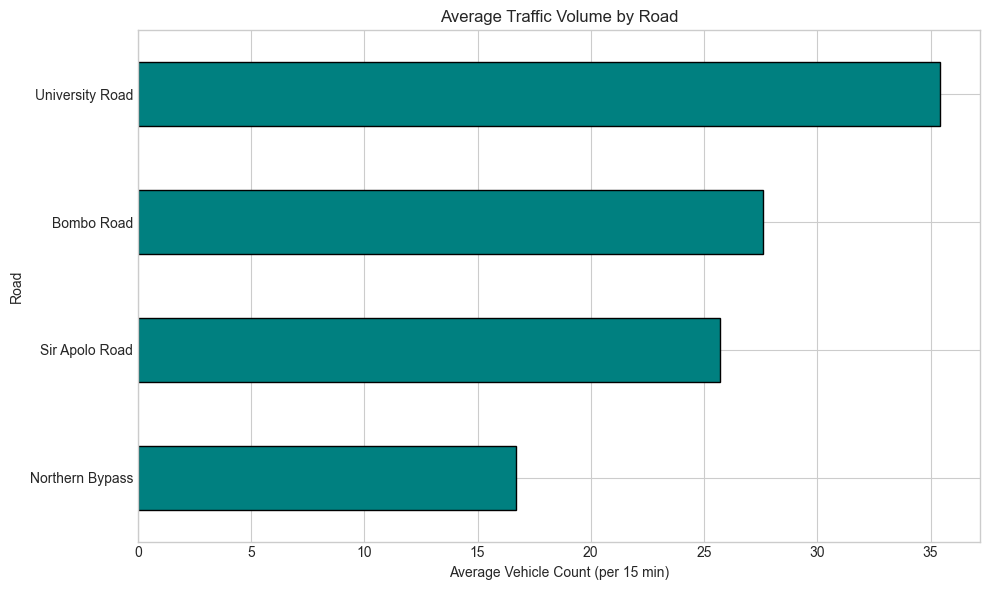

In [13]:
# Average traffic per road
road_avg = df.groupby('road')['estimated_vehicle_count'].mean().sort_values()

plt.figure(figsize=(10, 6))
road_avg.plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Average Vehicle Count (per 15 min)')
plt.ylabel('Road')
plt.title('Average Traffic Volume by Road')
plt.tight_layout()
plt.savefig('traffic_by_road.png', dpi=300)
plt.show()

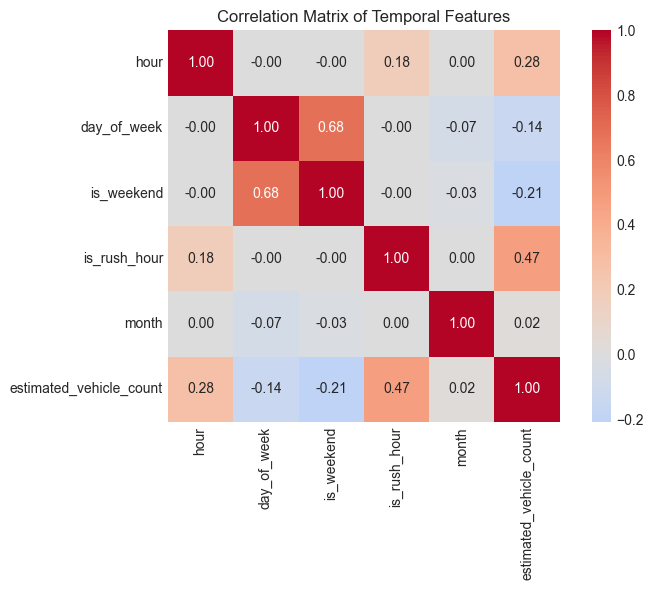

In [14]:
# Select numerical features for correlation
corr_features = ['hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'month', 'estimated_vehicle_count']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Temporal Features')
plt.tight_layout()
plt.savefig('traffic_correlation.png', dpi=300)
plt.show()

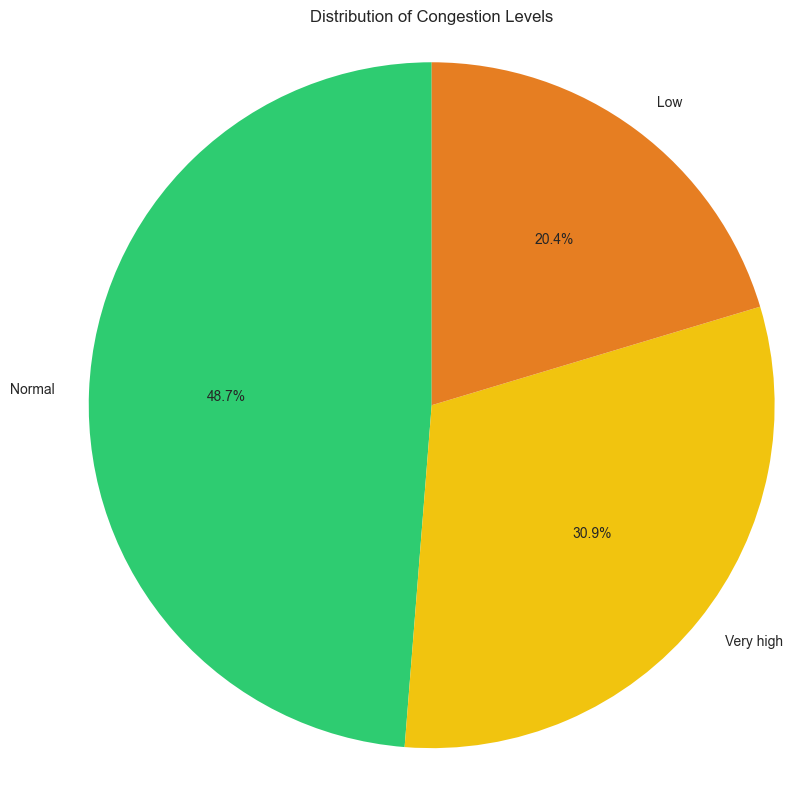

In [15]:
congestion_counts = df['congestion'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(congestion_counts.values, labels=congestion_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b'])
plt.title('Distribution of Congestion Levels')
plt.axis('equal')
plt.tight_layout()
plt.savefig('congestion_pie.png', dpi=300)
plt.show()

In [18]:
print("\nData types:\n", df.dtypes)


Data types:
 road                       object
datetime                   object
month                       int64
hour                        int64
day_of_week                 int64
is_weekend                  int64
is_rush_hour                int64
estimated_vehicle_count     int64
congestion                 object
dtype: object


In [19]:
print("\nBasic statistics:\n", df.describe(include='all'))


Basic statistics:
               road             datetime         month          hour  \
count        40320                40320  40320.000000  40320.000000   
unique           4                10080           NaN           NaN   
top     Bombo Road  2023-12-20 19:45:00           NaN           NaN   
freq         10080                    4           NaN           NaN   
mean           NaN                  NaN     10.019048     11.500000   
std            NaN                  NaN      1.264783      6.922272   
min            NaN                  NaN      8.000000      0.000000   
25%            NaN                  NaN      9.000000      5.750000   
50%            NaN                  NaN     10.000000     11.500000   
75%            NaN                  NaN     11.000000     17.250000   
max            NaN                  NaN     12.000000     23.000000   

         day_of_week    is_weekend  is_rush_hour  estimated_vehicle_count  \
count   40320.000000  40320.000000  40320.000000  